# 01. Exploratory Data Analysis

## Goal

This notebook explores the target distribution, missingness, numerical associations and selected categorical patterns in order to support downstream feature engineering.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


--- 1. dataframe ---
shape: (1460, 81)

type（20）：
Id                int64
MSSubClass        int64
MSZoning            str
LotFrontage     float64
LotArea           int64
Street              str
Alley               str
LotShape            str
LandContour         str
Utilities           str
LotConfig           str
LandSlope           str
Neighborhood        str
Condition1          str
Condition2          str
BldgType            str
HouseStyle          str
OverallQual       int64
OverallCond       int64
YearBuilt         int64
dtype: object

--- 2. target_col ---
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


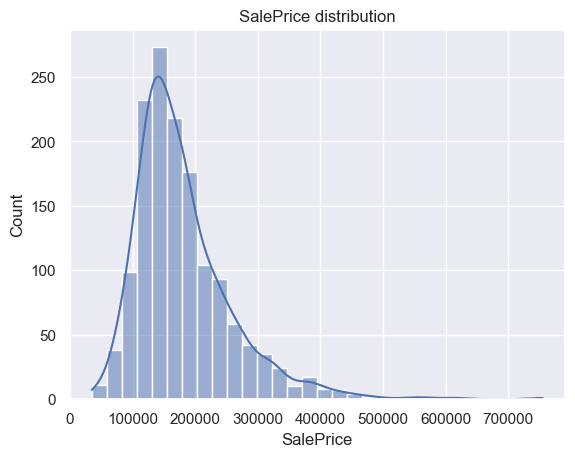

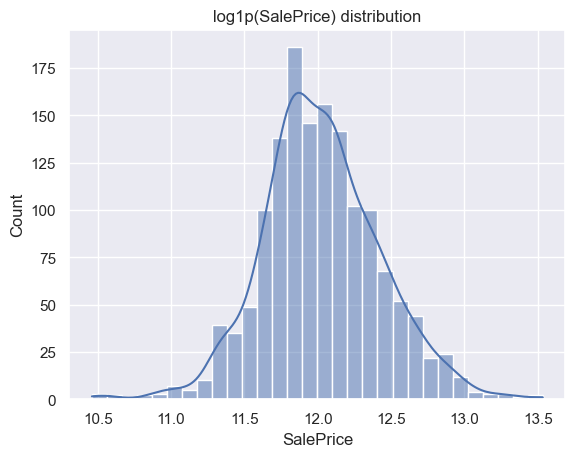


--- 3. missing_count（20） ---
              missing_count  missing_ratio
PoolQC                 1453       0.995205
MiscFeature            1406       0.963014
Alley                  1369       0.937671
Fence                  1179       0.807534
MasVnrType              872       0.597260
FireplaceQu             690       0.472603
LotFrontage             259       0.177397
GarageYrBlt              81       0.055479
GarageCond               81       0.055479
GarageType               81       0.055479
GarageFinish             81       0.055479
GarageQual               81       0.055479
BsmtFinType2             38       0.026027
BsmtExposure             38       0.026027
BsmtQual                 37       0.025342
BsmtCond                 37       0.025342
BsmtFinType1             37       0.025342
MasVnrArea                8       0.005479
Electrical                1       0.000685

--- 4. corr_to_target（20） ---
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
Gara

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
    
from eda import quick_eda, plot_top_corr_scatter, plot_cat_vs_target

quick_eda(df, "SalePrice")

## Missingness Analysis

The missingness pattern is highly structured rather than random.

- Features such as `PoolQC`, `Alley`, and `Fence` have extremely high missing ratios (>80%), which likely indicate the absence of the corresponding property rather than missing data. These should be treated as a separate category (e.g., "None").
- Mid-level missingness in variables like `FireplaceQu` and `LotFrontage` suggests potential dependency on underlying property characteristics, implying that missingness itself may carry information.
- Low missingness features (e.g., `Garage*`, `Bsmt*`) are more likely due to data collection issues and can be handled with standard imputation.

This suggests that missingness should be treated as a feature rather than simply removed.

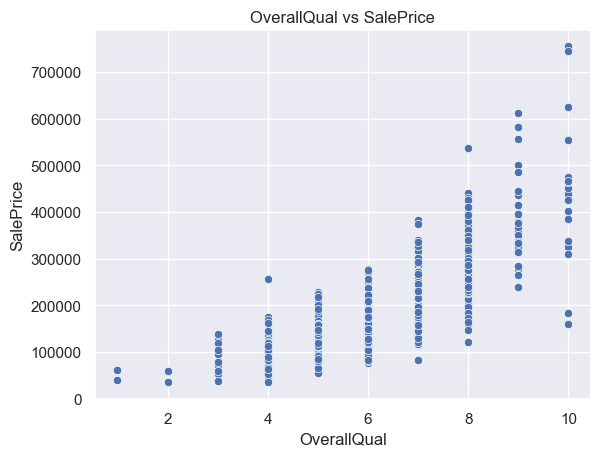

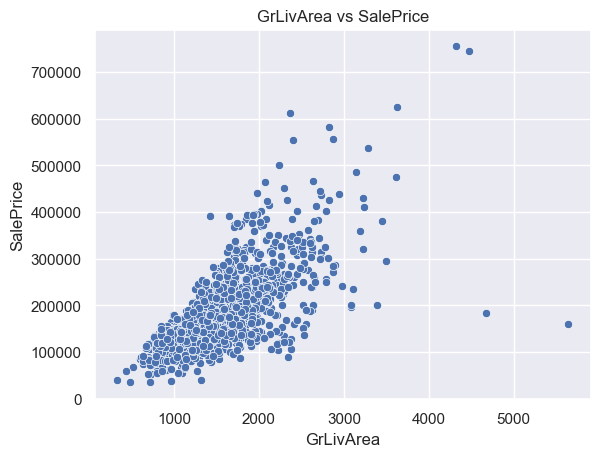

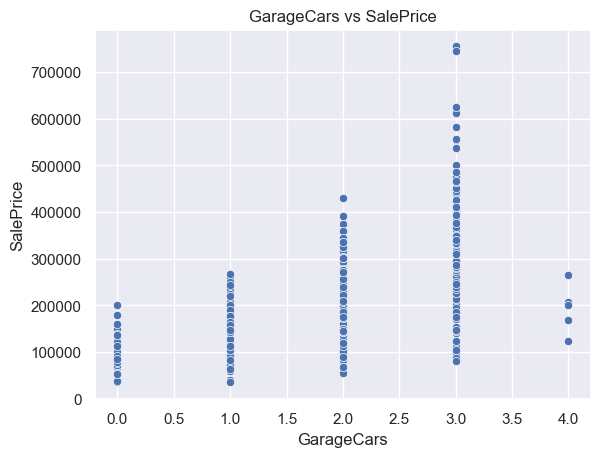

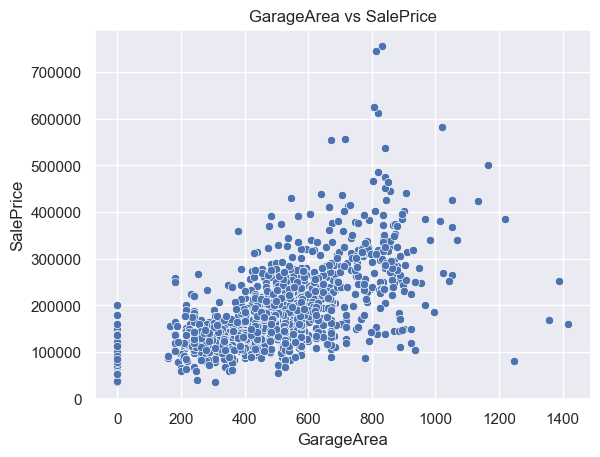

In [3]:
plot_top_corr_scatter(df, "SalePrice", top_n=4)

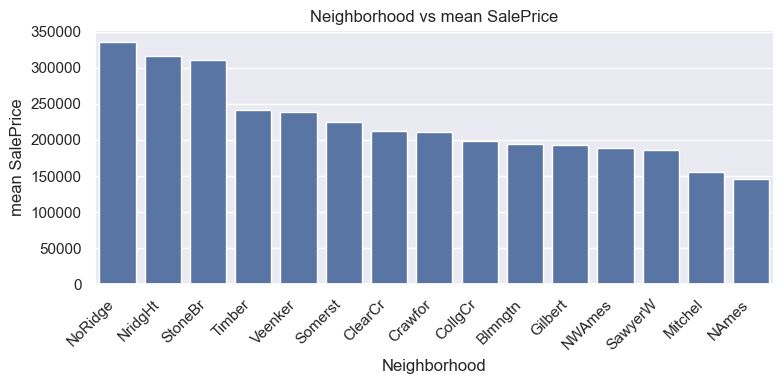

In [4]:
plot_cat_vs_target(df, "Neighborhood", "SalePrice", top_k=15)

## Categorical Feature Insight: Neighborhood

The variable `Neighborhood` shows clear variation in mean house price, indicating that location is a strong determinant of property value.

This variable likely acts as a proxy for multiple latent factors such as accessibility, school quality, and socio-economic conditions.

Therefore, encoding strategies for this variable (e.g., target encoding or model-based handling) will be critical in downstream modeling.

## EDA Summary

- The target variable is highly skewed and requires log transformation.
- Missingness is structured and should be treated as informative rather than random.
- Numerical correlations provide a useful first-pass filter but require validation via visualization.
- Categorical variables such as `Neighborhood` show strong explanatory power and require careful encoding.

These observations directly inform the next stage of feature engineering.